Arithmetic operation - image addition,subtraction, scalar multiplication

Logical Operations- AND, OR, NOT, XOR

Gray Level Transformation- Negative, Logarithmic,power law

Peicw wise gray level transformation - Thresholding.Contrasst strecting, Bit plan Slicing

##Arithmetic operation - image addition,subtraction, scalar multiplication

In [2]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt

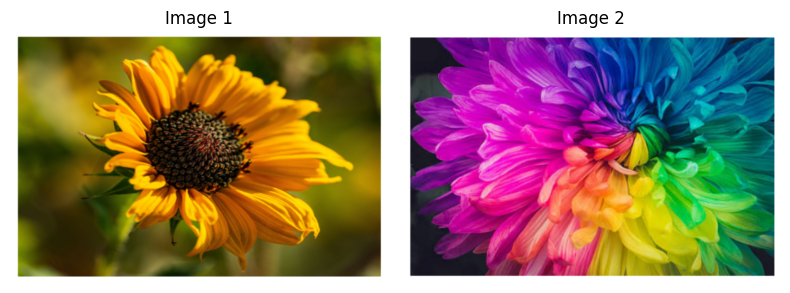

In [3]:
image1_original = cv2.imread('/content/download.png')
image2_original = cv2.imread('/content/download 1.png')

# Resize images to be of the same size and store in new variables
resized_image1=cv2.resize(image1_original,(600,400))
resized_image2=cv2.resize(image2_original,(600,400))

#Subplot images
plt.figure(figsize=(8,4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(resized_image1, cv2.COLOR_BGR2RGB))
plt.title('Image 1')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(resized_image2, cv2.COLOR_BGR2RGB))
plt.title('Image 2')
plt.axis('off')

plt.tight_layout()
plt.show()

### Grayscale Image Addition


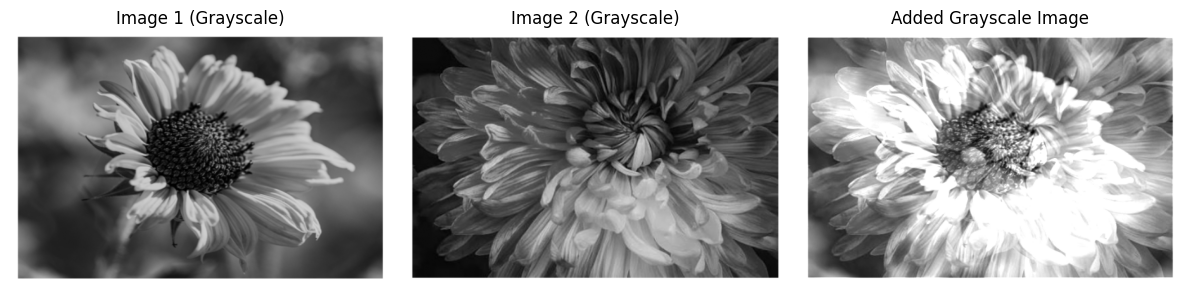

In [4]:
gray_resized_image1 = cv2.cvtColor(resized_image1, cv2.COLOR_BGR2GRAY)
gray_resized_image2 = cv2.cvtColor(resized_image2, cv2.COLOR_BGR2GRAY)

rows, cols = gray_resized_image1.shape
added_gray_image = np.zeros_like(gray_resized_image1, dtype=np.uint8)
for i in range(rows):
    for j in range(cols):
        # Cast to int before adding to prevent uint8 overflow
        pixel1 = int(gray_resized_image1[i, j])
        pixel2 = int(gray_resized_image2[i, j])
        Add = pixel1 + pixel2
        if Add > 255:
            added_gray_image[i, j] = 255  # Clip at 255
        else:
            added_gray_image[i, j] = Add

#Subplot the images
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(gray_resized_image1, cmap='gray')
plt.title('Image 1 (Grayscale)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gray_resized_image2, cmap='gray')
plt.title('Image 2 (Grayscale)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(added_gray_image, cmap='gray')
plt.title('Added Grayscale Image')
plt.axis('off')

plt.tight_layout()
plt.show()

###Adding binary images

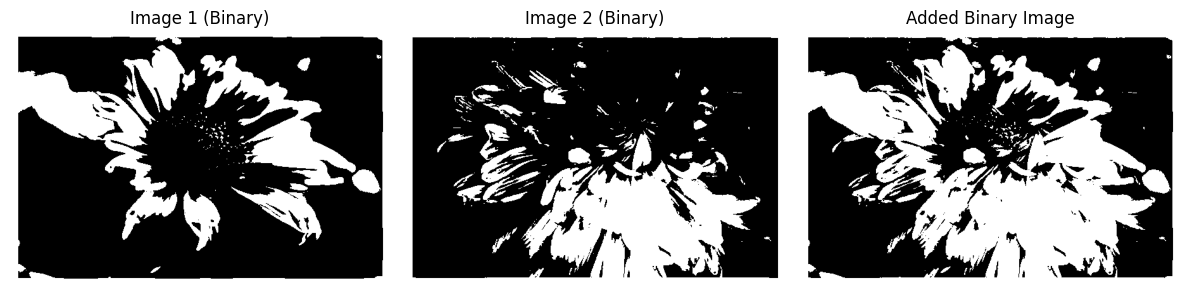

In [5]:
#Binary Images
binary_resized_image1 = cv2.threshold(gray_resized_image1, 127, 255, cv2.THRESH_BINARY)[1]
binary_resized_image2 = cv2.threshold(gray_resized_image2, 127, 255, cv2.THRESH_BINARY)[1]

#Adding two iamages using loop
added_binary_image=np.zeros((400,600),dtype=np.uint8)
for i in range(400):
  for j in range(600):
    pixel1=int(binary_resized_image1[i,j])
    pixel2=int(binary_resized_image2[i,j])
    if pixel1==255 or pixel2==255:
      added_binary_image[i,j]=255
    else:
      added_binary_image[i,j]=0

#Subplot images
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(binary_resized_image1, cmap='gray')
plt.title('Image 1 (Binary)')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(binary_resized_image2, cmap='gray')
plt.title('Image 2 (Binary)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(added_binary_image, cmap='gray')
plt.title('Added Binary Image')
plt.axis('off')

plt.tight_layout()
plt.show()

###Adding color images

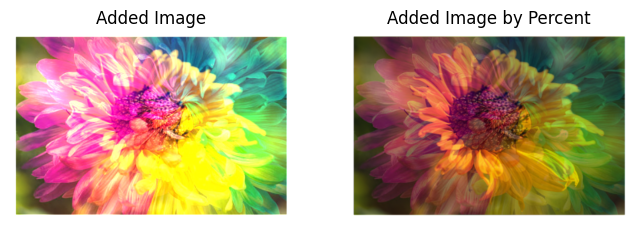

In [6]:
# Convert resized BGR images to RGB once and store in new variables
rgb_image1=cv2.cvtColor(resized_image1,cv2.COLOR_BGR2RGB)
rgb_image2=cv2.cvtColor(resized_image2,cv2.COLOR_BGR2RGB)

#Adding two images using loop (simple addition)
added_image=np.zeros((400,600,3),dtype=np.uint8)
for i in range(400):
  for j in range(600):
    for k in range(3):
      pixel1 = int(rgb_image1[i,j,k])
      pixel2 = int(rgb_image2[i,j,k])
      Add = pixel1 + pixel2
      if Add > 255:
        added_image[i,j,k]=255
      else:
        added_image[i,j,k]=Add

# Adding two images using loop with percentage blending
added_image_percent=np.zeros((400,600,3),dtype=np.uint8)
for i in range(400):
  for j in range(600):
    for k in range(3):
      Add=0.6*rgb_image1[i,j,k]+0.4*rgb_image2[i,j,k]
      if Add>255:
        added_image_percent[i,j,k]=Add%255
      else:
        added_image_percent[i,j,k]=Add

#Subplot added images
plt.figure(figsize=(8, 4))
plt.subplot(1,2,1)
plt.imshow(added_image)
plt.title('Added Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(added_image_percent)
plt.title('Added Image by Percent')
plt.axis('off')
plt.show()

##Scalar Multiplaction

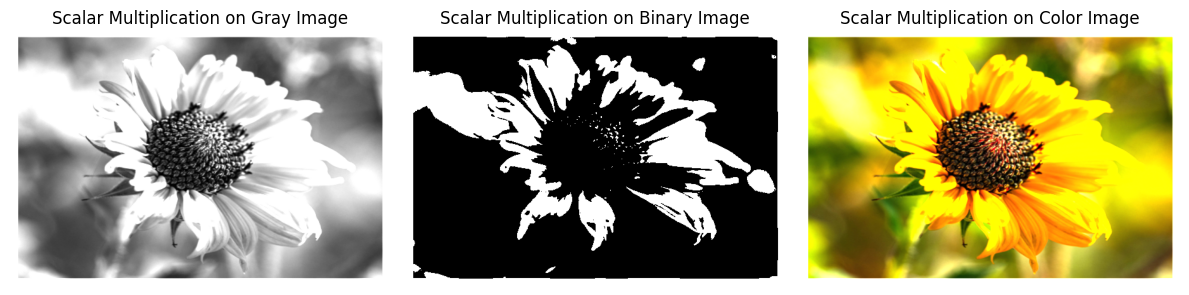

In [7]:
import matplotlib.pyplot as plt

# Scalar Multiplication on gray images using loop
scalar_gray_image=np.zeros((400,600),dtype=np.uint8)
for i in range(400):
  for j in range(600):
    pixel=int(gray_resized_image1[i,j])
    multiplied_pixel = pixel * 2 # Perform multiplication first
    if multiplied_pixel > 255:
      scalar_gray_image[i,j]=255 # Clip if over 255
    else:
      scalar_gray_image[i,j]=multiplied_pixel # Assign the calculated value

# Scalar Multiplication on Binary images using loop
scalar_binary_image=np.zeros((400,600),dtype=np.uint8)
for i in range(400):
  for j in range(600):
    pixel=int(binary_resized_image1[i,j])
    multiplied_pixel = pixel * 2 # Perform multiplication first
    if multiplied_pixel > 255:
      scalar_binary_image[i,j]=255 # Clip if over 255
    else:
      scalar_binary_image[i,j]=multiplied_pixel # Assign the calculated value

# Scalar Multiplaction on Color images
scalar_rgb_image=np.zeros((400,600,3),dtype=np.uint8)
for i in range(400):
  for j in range(600):
    for k in range(3):
      pixel=int(rgb_image1[i,j,k])
      multiplied_pixel = pixel * 2 # Perform multiplication first
      if multiplied_pixel > 255:
        scalar_rgb_image[i,j,k]=255 # Clip if over 255
      else:
        scalar_rgb_image[i,j,k]=multiplied_pixel # Assign the calculated value

# Display all three images in one figure with subplots
plt.figure(figsize=(12, 4)) # Create a single figure for the subplots

plt.subplot(1, 3, 1)
plt.imshow(scalar_gray_image, cmap='gray')
plt.title('Scalar Multiplication on Gray Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(scalar_binary_image, cmap='gray')
plt.title('Scalar Multiplication on Binary Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(scalar_rgb_image)
plt.title('Scalar Multiplication on Color Image')
plt.axis('off')

plt.tight_layout()
plt.show()

###  Image Subtraction

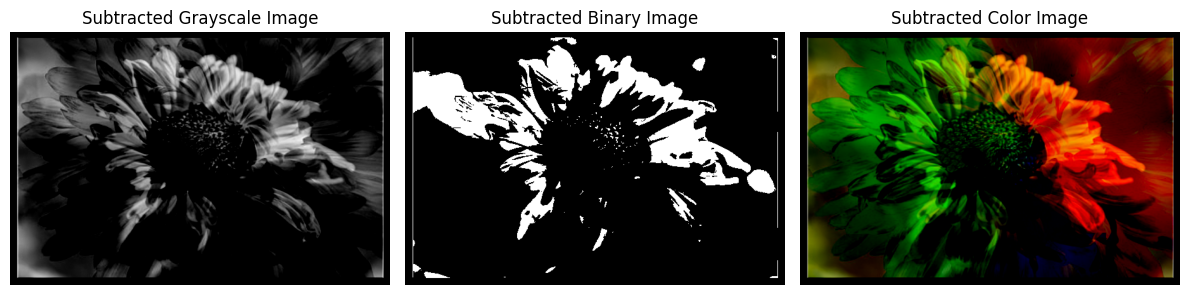

In [8]:
#binary, gray and color image subtraction
rows, cols = gray_resized_image1.shape

# Grayscale Image Subtraction
subtracted_gray_image = np.zeros((rows, cols), dtype=np.uint8)
for i in range(rows):
    for j in range(cols):
        pixel1 = int(gray_resized_image1[i, j])
        pixel2 = int(gray_resized_image2[i, j])
        diff_pixel = pixel1 - pixel2
        subtracted_gray_image[i, j] = max(0, diff_pixel)

# Binary Image Subtraction
subtracted_binary_image = np.zeros((rows, cols), dtype=np.uint8)
for i in range(rows):
    for j in range(cols):
        pixel1 = int(binary_resized_image1[i, j])
        pixel2 = int(binary_resized_image2[i, j])
        diff_pixel = pixel1 - pixel2
        subtracted_binary_image[i, j] = max(0, diff_pixel)

# Color Image Subtraction
subtracted_rgb_image = np.zeros_like(rgb_image1, dtype=np.uint8)
for i in range(rows):
    for j in range(cols):
        for k in range(3): # Iterate over RGB channels
            pixel1 = int(rgb_image1[i, j, k])
            pixel2 = int(rgb_image2[i, j, k])
            diff_pixel = pixel1 - pixel2
            subtracted_rgb_image[i, j, k] = max(0, diff_pixel)

# Display all three subtracted images in one figure with subplots
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(subtracted_gray_image, cmap='gray')
plt.title('Subtracted Grayscale Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(subtracted_binary_image, cmap='gray')
plt.title('Subtracted Binary Image')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(subtracted_rgb_image)
plt.title('Subtracted Color Image')
plt.axis('off')

plt.tight_layout()
plt.show()

#Gray Image Transformation

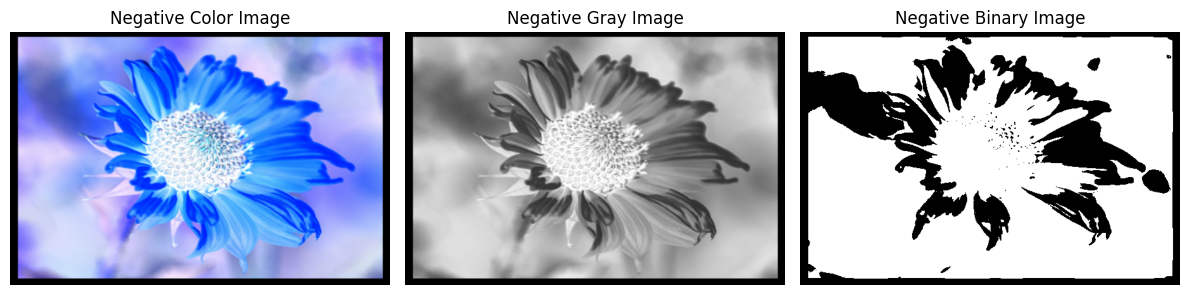

In [9]:
#Negative image of color,gray and binary images
negative_rgb_image=255-rgb_image1
negative_gray_resized_image=255-gray_resized_image1
negative_binary_resized_image=255-binary_resized_image1
#Subplot
plt.figure(figsize=(12, 4))
plt.subplot(1,3,1)
plt.imshow(negative_rgb_image)
plt.title('Negative Color Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(negative_gray_resized_image,cmap='gray')
plt.title('Negative Gray Image')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(negative_binary_resized_image,cmap='gray')
plt.title('Negative Binary Image')
plt.axis('off')

plt.tight_layout()
plt.show()

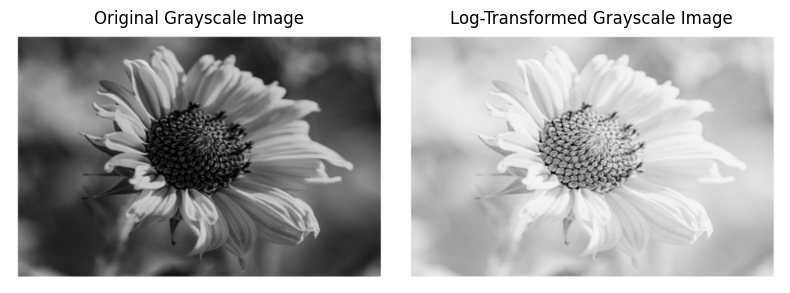

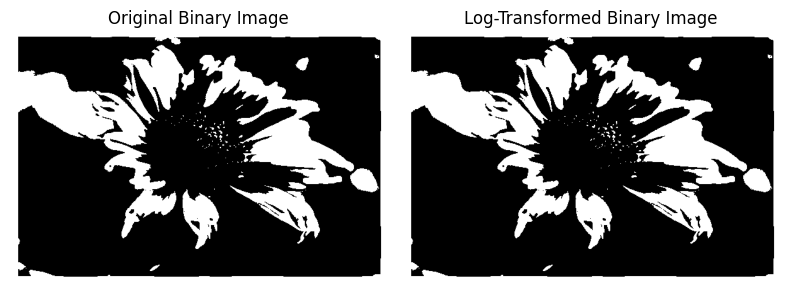

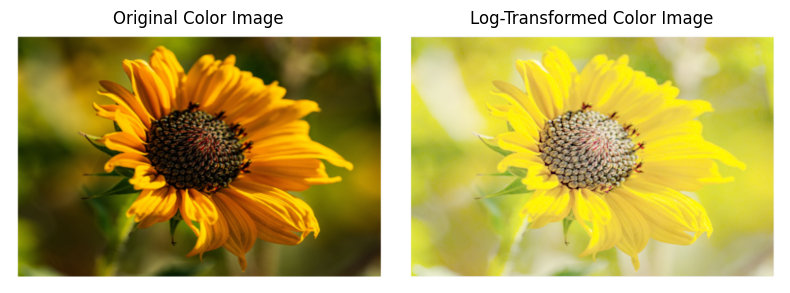

In [10]:
#Logirithimic operations on color,gray and binsry images
import numpy as np
import matplotlib.pyplot as plt

# It's crucial to convert images to float type before performing
# operations like adding 1 and taking log, to avoid uint8 overflow
# and ensure proper floating-point calculations.

# Logarithmic Transformation on Grayscale Image
gray_resized_image1_float = gray_resized_image1.astype(np.float64)
# Constant for scaling the logarithmic transformation
# Use the maximum value from the float version of the image
c = 255 / np.log(1 + np.max(gray_resized_image1_float))
log_gray_image = c * np.log(1 + gray_resized_image1_float)
log_gray_image = np.clip(log_gray_image, 0, 255) # Clip to 0-255 range
log_gray_image = log_gray_image.astype(np.uint8)

# Logarithmic Transformation on Binary Image
binary_resized_image1_float = binary_resized_image1.astype(np.float64)
c_binary = 255 / np.log(1 + np.max(binary_resized_image1_float)) # Recalculate c for binary if max pixel value differs
log_binary_image = c_binary * np.log(1 + binary_resized_image1_float)
log_binary_image = np.clip(log_binary_image, 0, 255)
log_binary_image = log_binary_image.astype(np.uint8)

# Logarithmic Transformation on Color Image
rgb_image1_float = rgb_image1.astype(np.float64)
c_color = 255 / np.log(1 + np.max(rgb_image1_float))
log_color_image = c_color * np.log(1 + rgb_image1_float)
log_color_image = np.clip(log_color_image, 0, 255)
log_color_image = log_color_image.astype(np.uint8)

# Display Original and Log-Transformed Grayscale Image
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(gray_resized_image1, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(log_gray_image, cmap='gray')
plt.title('Log-Transformed Grayscale Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# Display Original and Log-Transformed Binary Image
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(binary_resized_image1, cmap='gray')
plt.title('Original Binary Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(log_binary_image, cmap='gray')
plt.title('Log-Transformed Binary Image')
plt.axis('off')
plt.tight_layout()
plt.show()

# Display Original and Log-Transformed Color Image
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(rgb_image1)
plt.title('Original Color Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(log_color_image)
plt.title('Log-Transformed Color Image')
plt.axis('off')
plt.tight_layout()
plt.show()

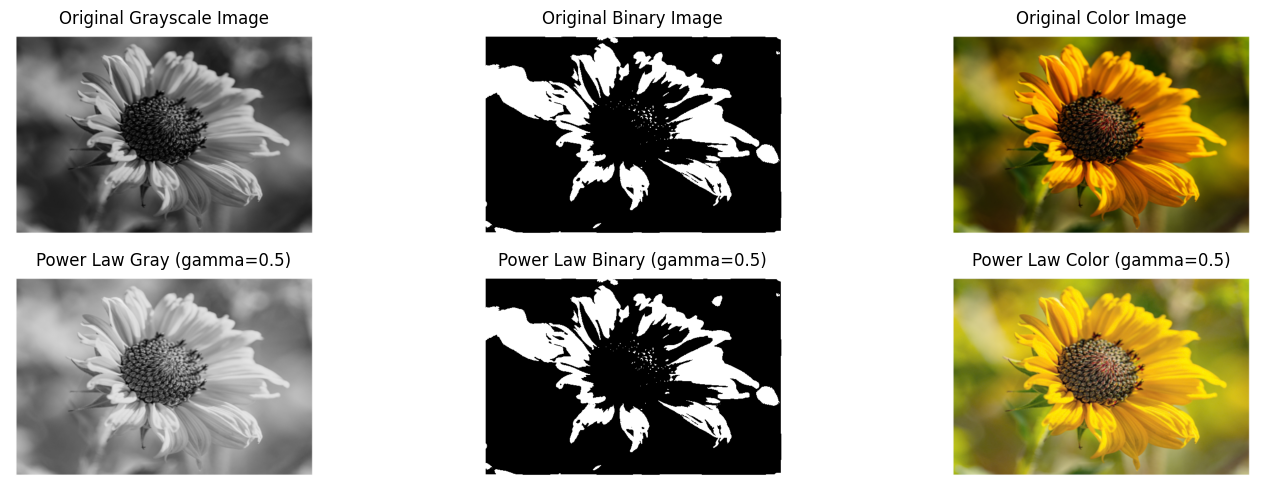

In [13]:
#Power Law
import numpy as np
import matplotlib.pyplot as plt

# Define gamma value
gamma = 0.5  # Adjust this value: <1 for brighter, >1 for darker
c = 1 # Scaling constant, often 1 when normalizing input to [0,1]

# Power Law Transformation on Grayscale Image
gray_resized_image1_normalized = gray_resized_image1 / 255.0 # Normalize to [0, 1]
power_law_gray_image = c * np.power(gray_resized_image1_normalized, gamma) * 255.0 # Apply power law and scale back
power_law_gray_image = np.clip(power_law_gray_image, 0, 255).astype(np.uint8)

# Power Law Transformation on Binary Image (less common, but for completeness)
binary_resized_image1_normalized = binary_resized_image1 / 255.0 # Normalize to [0, 1]
power_law_binary_image = c * np.power(binary_resized_image1_normalized, gamma) * 255.0
power_law_binary_image = np.clip(power_law_binary_image, 0, 255).astype(np.uint8)

# Power Law Transformation on Color Image
rgb_image1_normalized = rgb_image1 / 255.0 # Normalize to [0, 1]
power_law_rgb_image = c * np.power(rgb_image1_normalized, gamma) * 255.0
power_law_rgb_image = np.clip(power_law_rgb_image, 0, 255).astype(np.uint8)

# Display Original and Power Law Transformed Images
plt.figure(figsize=(15, 5))

plt.subplot(2, 3, 1)
plt.imshow(gray_resized_image1, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(binary_resized_image1, cmap='gray')
plt.title('Original Binary Image')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(rgb_image1)
plt.title('Original Color Image')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(power_law_gray_image, cmap='gray')
plt.title(f'Power Law Gray (gamma={gamma})')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(power_law_binary_image, cmap='gray')
plt.title(f'Power Law Binary (gamma={gamma})')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(power_law_rgb_image)
plt.title(f'Power Law Color (gamma={gamma})')
plt.axis('off')

plt.tight_layout()
plt.show()

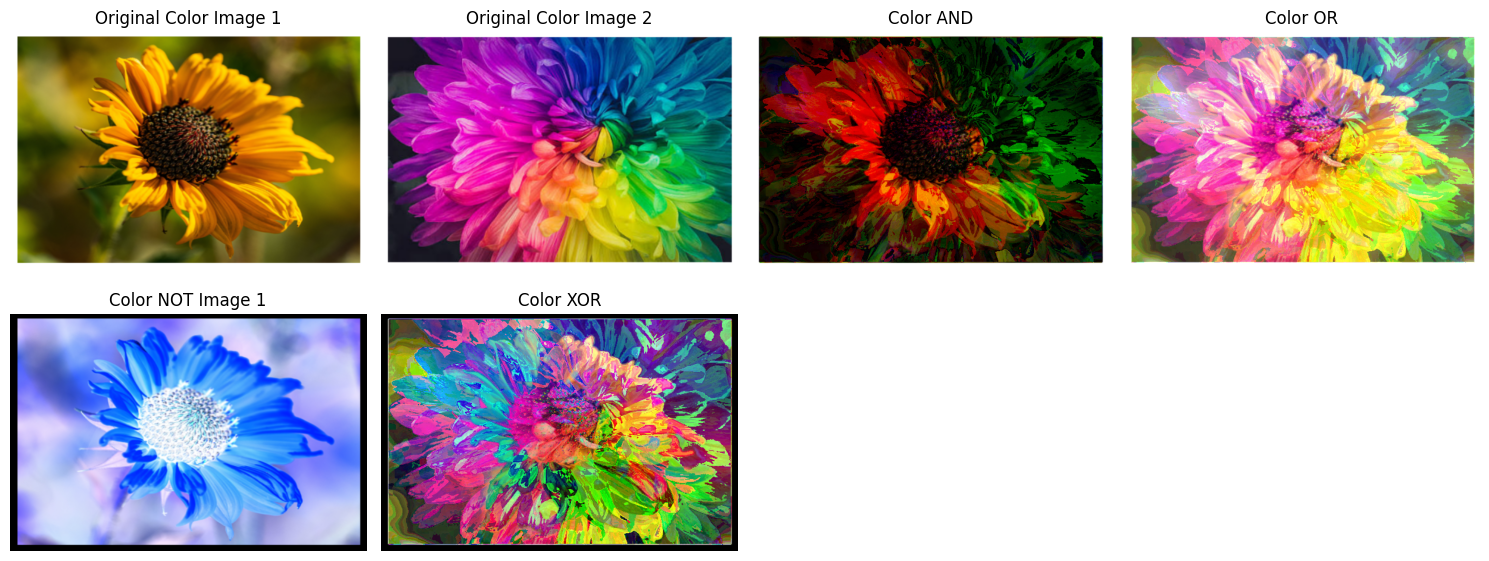

In [12]:
#Logical operations (AND, OR, NOT, XOR) to the color images
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Logical AND operation on color images
and_rgb_image = cv2.bitwise_and(rgb_image1, rgb_image2)

# Logical OR operation on color images
or_rgb_image = cv2.bitwise_or(rgb_image1, rgb_image2)

# Logical NOT operation on color image
not_rgb_image = cv2.bitwise_not(rgb_image1)

# Logical XOR operation on color images
xor_rgb_image = cv2.bitwise_xor(rgb_image1, rgb_image2)

# Display Color Logical Operations
plt.figure(figsize=(15, 6))

plt.subplot(2, 4, 1)
plt.imshow(rgb_image1)
plt.title('Original Color Image 1')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(rgb_image2)
plt.title('Original Color Image 2')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(and_rgb_image)
plt.title('Color AND')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(or_rgb_image)
plt.title('Color OR')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(not_rgb_image)
plt.title('Color NOT Image 1')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(xor_rgb_image)
plt.title('Color XOR')
plt.axis('off')

plt.tight_layout()
plt.show()

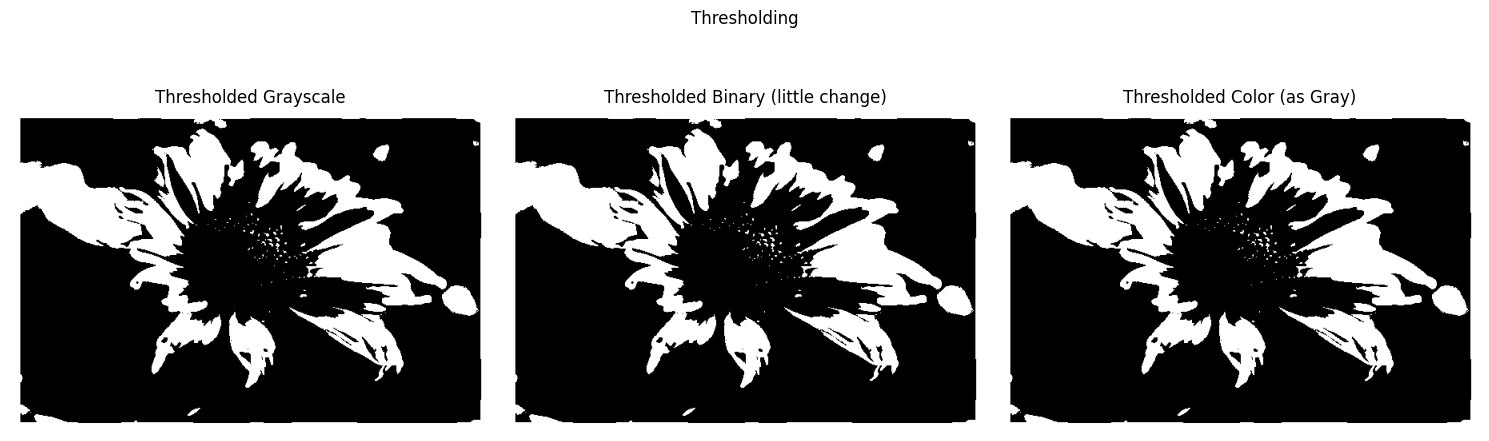

In [17]:
# Resize image for consistency, assuming a standard size like 600x400
resized_image1 = cv2.resize(image1_original, (600, 400))

# Prepare grayscale, binary, and RGB versions of the image
gray_resized_image1 = cv2.cvtColor(resized_image1, cv2.COLOR_BGR2GRAY)
# For binary, apply a threshold to the grayscale image
_, binary_resized_image1 = cv2.threshold(gray_resized_image1, 127, 255, cv2.THRESH_BINARY)
rgb_image1 = cv2.cvtColor(resized_image1, cv2.COLOR_BGR2RGB)


# --- 1. Thresholding ---

# Global threshold value
threshold_value = 127

# Thresholding on Grayscale Image
thresh_gray = np.zeros_like(gray_resized_image1, dtype=np.uint8)
rows, cols = gray_resized_image1.shape
for i in range(rows):
    for j in range(cols):
        if gray_resized_image1[i, j] > threshold_value:
            thresh_gray[i, j] = 255
        else:
            thresh_gray[i, j] = 0

# Thresholding on Binary Image (will typically result in the same image if threshold is between 0 and 255)
thresh_binary = np.zeros_like(binary_resized_image1, dtype=np.uint8)
for i in range(rows):
    for j in range(cols):
        if binary_resized_image1[i, j] > threshold_value:
            thresh_binary[i, j] = 255
        else:
            thresh_binary[i, j] = 0

# Thresholding on Color Image (convert to grayscale first)
gray_from_color = cv2.cvtColor(rgb_image1, cv2.COLOR_RGB2GRAY)
thresh_color = np.zeros_like(gray_from_color, dtype=np.uint8)
for i in range(rows):
    for j in range(cols):
        if gray_from_color[i, j] > threshold_value:
            thresh_color[i, j] = 255
        else:
            thresh_color[i, j] = 0

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(thresh_gray, cmap='gray')
plt.title('Thresholded Grayscale')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_binary, cmap='gray')
plt.title('Thresholded Binary (little change)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(thresh_color, cmap='gray')
plt.title('Thresholded Color (as Gray)')
plt.axis('off')
plt.suptitle('Thresholding')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

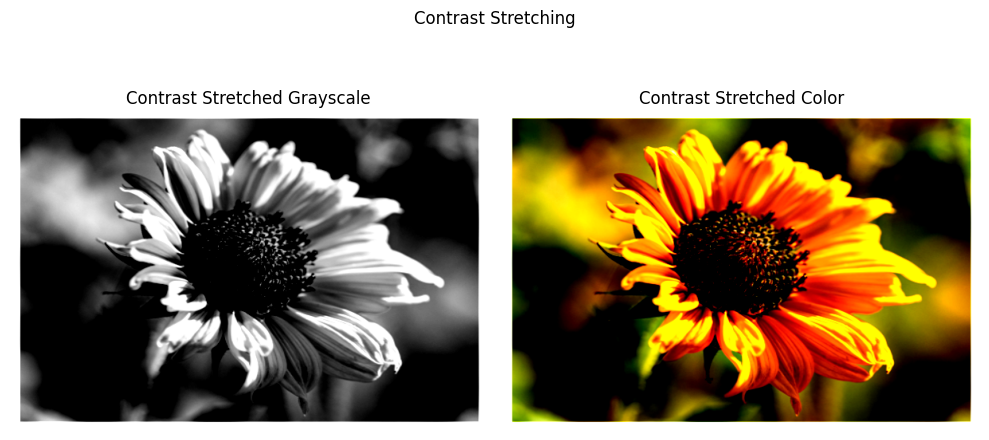

In [20]:

# --- 2. Contrast Stretching ---

# Parameters for piecewise linear contrast stretching
r1, s1 = 70, 0
r2, s2 = 180, 255

# Contrast Stretching on Grayscale Image
stretched_gray = np.zeros_like(gray_resized_image1, dtype=np.uint8)
gray_float = gray_resized_image1.astype(np.float32)
for i in range(rows):
    for j in range(cols):
        pixel_val = gray_float[i, j]
        output_val = 0.0
        if pixel_val < r1:
            output_val = (s1 / r1) * pixel_val if r1 != 0 else 0
        elif r1 <= pixel_val <= r2:
            output_val = ((s2 - s1) / (r2 - r1)) * (pixel_val - r1) + s1 if (r2 - r1) != 0 else s1
        else: # pixel_val > r2
            output_val = ((255 - s2) / (255 - r2)) * (pixel_val - r2) + s2 if (255 - r2) != 0 else s2
        stretched_gray[i, j] = np.clip(output_val, 0, 255).astype(np.uint8)

# Contrast Stretching on Color Image (channel-wise)
stretched_color = np.zeros_like(rgb_image1, dtype=np.uint8)
rgb_float = rgb_image1.astype(np.float32)
height, width, channels = rgb_float.shape

for c_idx in range(channels):
    for i in range(height):
        for j in range(width):
            pixel_val = rgb_float[i, j, c_idx]
            output_val = 0.0
            if pixel_val < r1:
                output_val = (s1 / r1) * pixel_val if r1 != 0 else 0
            elif r1 <= pixel_val <= r2:
                output_val = ((s2 - s1) / (r2 - r1)) * (pixel_val - r1) + s1 if (r2 - r1) != 0 else s1
            else: # pixel_val > r2
                output_val = ((255 - s2) / (255 - r2)) * (pixel_val - r2) + s2 if (255 - r2) != 0 else s2
            stretched_color[i, j, c_idx] = np.clip(output_val, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(stretched_gray, cmap='gray')
plt.title('Contrast Stretched Grayscale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(stretched_color)
plt.title('Contrast Stretched Color')
plt.axis('off')
plt.suptitle('Contrast Stretching')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##Assignment
From the blended image segregate to original image

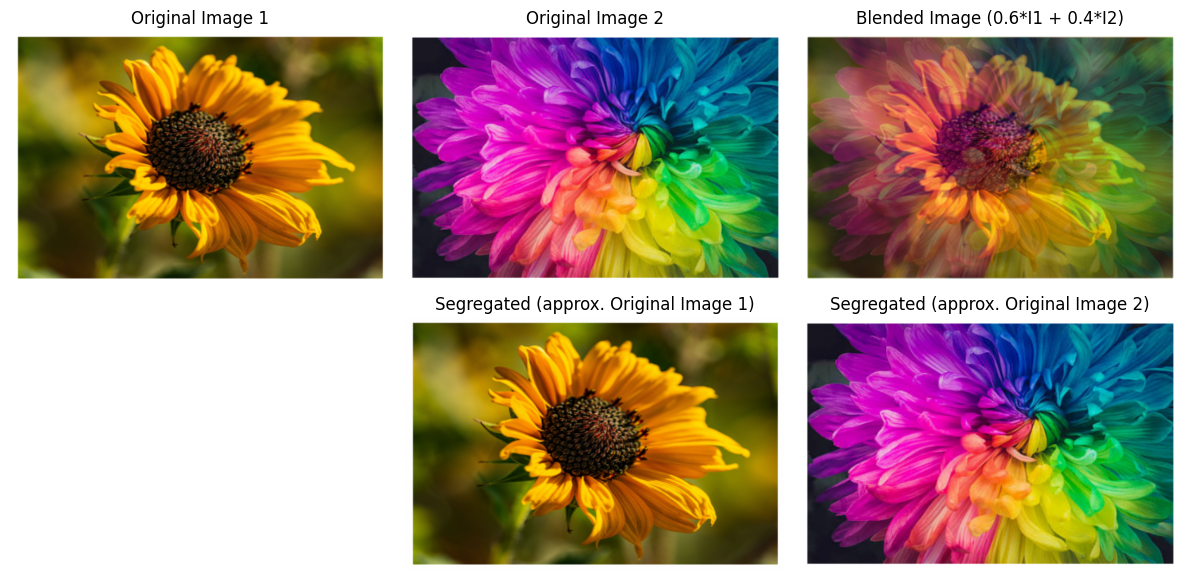

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Use the RGB versions of the resized original images
# Convert images to float for accurate mathematical operations (subtraction and division)
added_image_percent_float = added_image_percent.astype(np.float32)
rgb_image1_float = rgb_image1.astype(np.float32)
rgb_image2_float = rgb_image2.astype(np.float32)

# Attempt to recover Image 1 using the inverse of the blending formula:
# blended = 0.6 * image1 + 0.4 * image2
# image1 = (blended - 0.4 * image2) / 0.6
recovered_image1_attempt = (added_image_percent_float - (0.4 * rgb_image2_float)) / 0.6

# Attempt to recover Image 2 using the inverse of the blending formula:
# image2 = (blended - 0.6 * image1) / 0.4
recovered_image2_attempt = (added_image_percent_float - (0.6 * rgb_image1_float)) / 0.4

# Clip the recovered images to the valid 0-255 range and convert back to uint8
recovered_image1_attempt = np.clip(recovered_image1_attempt, 0, 255).astype(np.uint8)
recovered_image2_attempt = np.clip(recovered_image2_attempt, 0, 255).astype(np.uint8)

# Display the original, blended, and segregated images
plt.figure(figsize=(12, 6))

# Row 1: Original Images and Blended Image
plt.subplot(2, 3, 1)
plt.imshow(rgb_image1)
plt.title('Original Image 1')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(rgb_image2)
plt.title('Original Image 2')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(added_image_percent)
plt.title('Blended Image (0.6*I1 + 0.4*I2)')
plt.axis('off')

# Row 2: Recovered Images
plt.subplot(2, 3, 5) # Placed in the middle of the second row for better visual flow
plt.imshow(recovered_image1_attempt)
plt.title('Segregated (approx. Original Image 1)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(recovered_image2_attempt)
plt.title('Segregated (approx. Original Image 2)')
plt.axis('off')

plt.tight_layout()
plt.show()